# Импорт библиотек

In [24]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw

from main import build_dataframe, ensure_bccd, prepare_yolo_dataset, split_dataframe

In [3]:
ROOT = Path.cwd()
if not (ROOT / "main.py").exists():
    candidate = (ROOT / "practice/neural_networks/bccd").resolve()
    if candidate.exists():
        os.chdir(candidate)
        ROOT = candidate

WORK_DIR = ROOT / "bccd_work"
DATA_DIR = ROOT / "data"
DATASET_CSV = WORK_DIR / "bccd_dataset.csv"
METRICS_JSON = WORK_DIR / "metrics.json"
YOLO_YAML = WORK_DIR / "yolo_dataset" / "bccd.yaml"
CLASSES = ["RBC", "WBC", "Platelets"]

WORK_DIR.mkdir(parents=True, exist_ok=True)
print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
print("dataset csv:", DATASET_CSV.exists(), DATASET_CSV)
print("metrics:", METRICS_JSON.exists(), METRICS_JSON)

ROOT: /Users/lunis/PycharmProjects/machine_learning/practice/neural_networks/bccd
DATA_DIR: /Users/lunis/PycharmProjects/machine_learning/practice/neural_networks/bccd/data
dataset csv: True /Users/lunis/PycharmProjects/machine_learning/practice/neural_networks/bccd/bccd_work/bccd_dataset.csv
metrics: True /Users/lunis/PycharmProjects/machine_learning/practice/neural_networks/bccd/bccd_work/metrics.json


# Загрузка датасета

In [5]:
if DATASET_CSV.exists():
    print("Использую готовый CSV:", DATASET_CSV)
    df = pd.read_csv(DATASET_CSV)
    df["boxes"] = df["boxes"].apply(json.loads)
else:
    print("CSV не найден. Скачиваю и парсю BCCD...")
    bccd_root = ensure_bccd(DATA_DIR)
    df = build_dataframe(bccd_root, DATASET_CSV)
    print("CSV сохранен:", DATASET_CSV)

CSV не найден. Скачиваю и парсю BCCD...


master.zip: 7.93MB [00:01, 7.60MB/s]


CSV сохранен: /Users/lunis/PycharmProjects/machine_learning/practice/neural_networks/bccd/bccd_work/bccd_dataset.csv


In [6]:
count_cols = CLASSES + ["total_cells"]
print(f"images: {len(df)}")
print(f"objects: {int(df[CLASSES].sum().sum())}")
df.head()

images: 364
objects: 4888


,image_id,image_path,xml_path,width,height,boxes,RBC,WBC,Platelets,total_cells
0,BloodImage_00000,/Users/lunis/PycharmProjects/machine_learning/...,/Users/lunis/PycharmProjects/machine_learning/...,640,480,"[{'class': 'WBC', 'xmin': 260.0, 'ymin': 177.0...",19,1,0,20
1,BloodImage_00001,/Users/lunis/PycharmProjects/machine_learning/...,/Users/lunis/PycharmProjects/machine_learning/...,640,480,"[{'class': 'WBC', 'xmin': 68.0, 'ymin': 315.0,...",18,1,0,19
2,BloodImage_00002,/Users/lunis/PycharmProjects/machine_learning/...,/Users/lunis/PycharmProjects/machine_learning/...,640,480,"[{'class': 'RBC', 'xmin': 385.0, 'ymin': 98.0,...",15,1,0,16
3,BloodImage_00003,/Users/lunis/PycharmProjects/machine_learning/...,/Users/lunis/PycharmProjects/machine_learning/...,640,480,"[{'class': 'WBC', 'xmin': 127.0, 'ymin': 40.0,...",15,1,1,17
4,BloodImage_00004,/Users/lunis/PycharmProjects/machine_learning/...,/Users/lunis/PycharmProjects/machine_learning/...,640,480,"[{'class': 'WBC', 'xmin': 109.0, 'ymin': 134.0...",11,1,1,13


In [7]:
summary = df[count_cols + ["width", "height"]].describe().T.round(2)
summary

,count,mean,std,min,25%,50%,75%,max
RBC,364.0,11.41,4.27,0.0,9.0,11.0,14.0,27.0
WBC,364.0,1.02,0.23,0.0,1.0,1.0,1.0,2.0
Platelets,364.0,0.99,1.15,0.0,0.0,1.0,2.0,6.0
total_cells,364.0,13.43,4.47,1.0,11.0,14.0,16.0,30.0
width,364.0,640.00,0.00,640.0,640.0,640.0,640.0,640.0
height,364.0,480.00,0.00,480.0,480.0,480.0,480.0,480.0


In [9]:
if YOLO_YAML.exists():
    print("YOLO dataset уже подготовлен:", YOLO_YAML)
else:
    train_df, val_df = split_dataframe(df, seed=42)
    yaml_path = prepare_yolo_dataset(train_df, val_df, WORK_DIR / "yolo_dataset")
    print("YOLO dataset подготовлен:", yaml_path)

print(YOLO_YAML.read_text(encoding="utf-8") if YOLO_YAML.exists() else "YOLO yaml пока не найден")

YOLO dataset уже подготовлен: /Users/lunis/PycharmProjects/machine_learning/practice/neural_networks/bccd/bccd_work/yolo_dataset/bccd.yaml
path: C:\Users\linus\PycharmProjects\machine_learning\practice\neural_networks\bccd\bccd_work\yolo_dataset
train: images/train
val: images/val
names:
  0: RBC
  1: WBC
  2: Platelets



# EDA

BCCD сильно несбалансирован: эритроцитов (`RBC`) существенно больше, чем лейкоцитов (`WBC`) и тромбоцитов (`Platelets`). Это важно для обеих постановок: регрессор может переобучаться на доминирующий класс, а YOLO будет получать меньше позитивных примеров малых классов.

In [10]:
class_totals = df[CLASSES].sum().sort_values(ascending=False)
class_share = (class_totals / class_totals.sum()).rename("share")
class_report = pd.concat([class_totals.rename("objects"), class_share], axis=1)
class_report["share"] = (100 * class_report["share"]).round(2)
class_report

,objects,share
RBC,4155,85.00
WBC,372,7.61
Platelets,361,7.39


Вывод: Датасет сильно несбалансирован

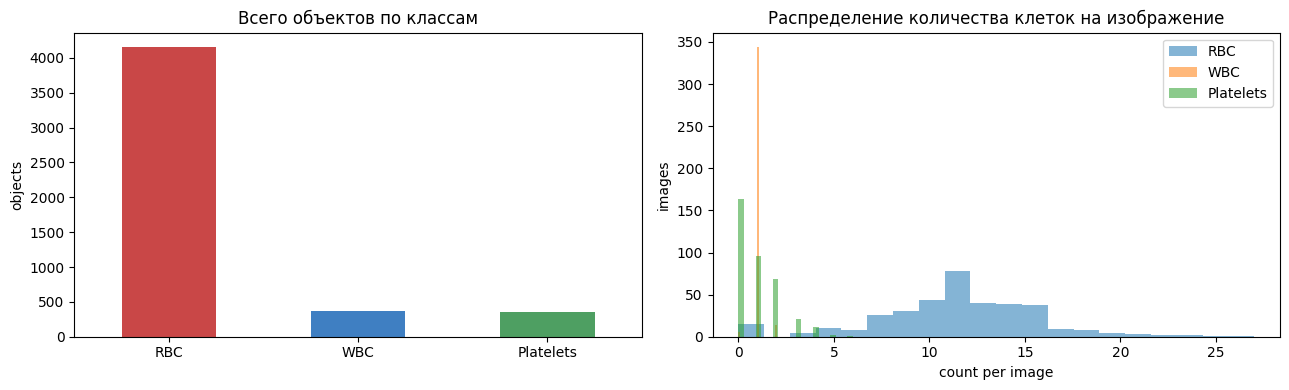

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

class_totals.plot(kind="bar", ax=axes[0], color=["#c94747", "#3f7fc2", "#4e9f62"])
axes[0].set_title("Всего объектов по классам")
axes[0].set_ylabel("objects")
axes[0].tick_params(axis="x", rotation=0)

for cls in CLASSES:
    axes[1].hist(df[cls], bins=20, alpha=0.55, label=cls)
axes[1].set_title("Распределение количества клеток на изображение")
axes[1].set_xlabel("count per image")
axes[1].set_ylabel("images")
axes[1].legend()

plt.tight_layout()

Вывод:
- RBC присутствуют почти на каждом изображени их много на изображение
- Большинство изображений либо 0 WBC либо 1 WBC

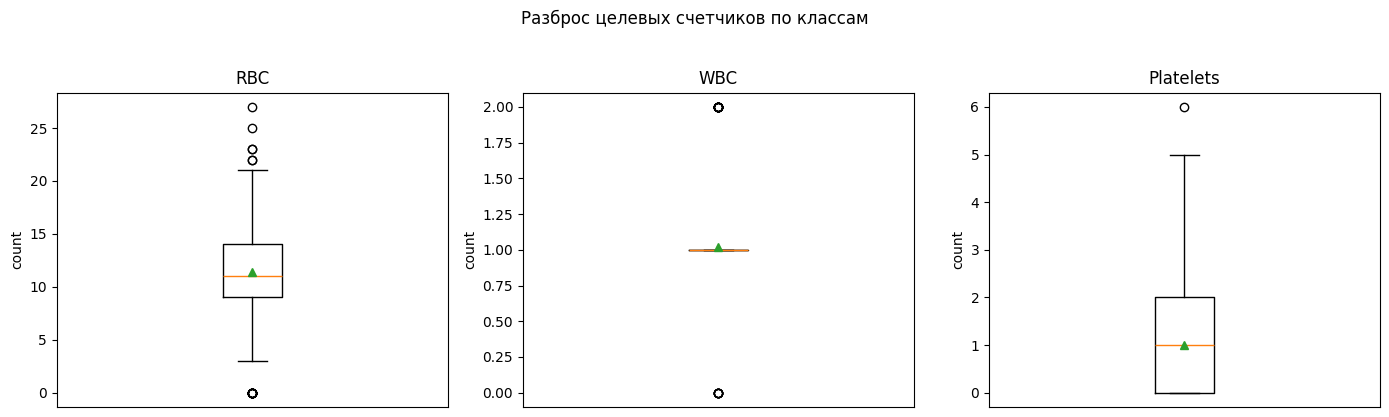

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, cls in zip(axes, CLASSES):
    ax.boxplot(df[cls], vert=True, showmeans=True)
    ax.set_title(cls)
    ax.set_ylabel("count")
    ax.set_xticks([])

plt.suptitle("Разброс целевых счетчиков по классам", y=1.03)
plt.tight_layout()

Вывод:
- RBC — доминирующий класс с большим разбросом
- WBC — почти всегда ровно 1 объект
- Platelets — часто отсутствуют
- Распределение по изображениям крайне неравномерное

In [13]:
corr = df[count_cols].corr().round(2)
corr

,RBC,WBC,Platelets,total_cells
RBC,1.00,0.00,0.04,0.96
WBC,0.00,1.00,0.02,0.06
Platelets,0.04,0.02,1.00,0.30
total_cells,0.96,0.06,0.30,1.00


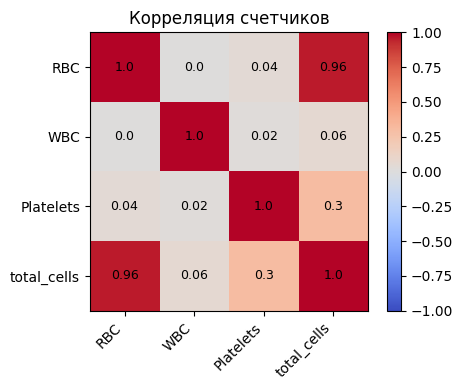

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.index)), corr.index)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, corr.iloc[i, j], ha="center", va="center", fontsize=9)
ax.set_title("Корреляция счетчиков")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()

Вывод:
- total_cells почти полностью определяется RBC (corr = 0.96)
- WBC почти не влияет на общую структуру сцены (corr = 0.06)
- Platelets имеет слабое влияние (corr = 0.30)
- Классы между собой практически независимы

Для YOLO целевой признак строится из bbox: `class x_center y_center width height`, нормированных на размер изображения. Ниже bbox разворачиваются в отдельную таблицу, чтобы проверить размеры объектов и вклад каждого класса.

In [15]:
box_rows = []
for _, row in df.iterrows():
    for box in row["boxes"]:
        width = box["xmax"] - box["xmin"]
        height = box["ymax"] - box["ymin"]
        box_rows.append({
            "image_id": row["image_id"],
            "class": box["class"],
            "xmin": box["xmin"],
            "ymin": box["ymin"],
            "xmax": box["xmax"],
            "ymax": box["ymax"],
            "box_width": width,
            "box_height": height,
            "box_area": width * height,
            "relative_area": (width * height) / (row["width"] * row["height"]),
        })

In [16]:
boxes_df = pd.DataFrame(box_rows)
print(f"boxes: {len(boxes_df)}")
boxes_df.head()

boxes: 4888


,image_id,class,xmin,ymin,xmax,ymax,box_width,box_height,box_area,relative_area
0,BloodImage_00000,WBC,260.0,177.0,491.0,376.0,231.0,199.0,45969.0,0.149639
1,BloodImage_00000,RBC,78.0,336.0,184.0,435.0,106.0,99.0,10494.0,0.034160
2,BloodImage_00000,RBC,63.0,237.0,169.0,336.0,106.0,99.0,10494.0,0.034160
3,BloodImage_00000,RBC,214.0,362.0,320.0,461.0,106.0,99.0,10494.0,0.034160
4,BloodImage_00000,RBC,414.0,352.0,506.0,445.0,92.0,93.0,8556.0,0.027852


Вывод:
- Ошибок в разметке не видно
- WBC примерно в 4–5 раз больше, чем RBC.
- Размер RBC почти константный

In [17]:
box_stats = boxes_df.groupby("class")[["box_width", "box_height", "box_area", "relative_area"]].agg(["count", "mean", "median", "std"]).round(3)
box_stats

box_width                         box_height                  \
              count     mean median     std      count     mean median   
class                                                                    
Platelets       361   41.576   39.0  12.283        361   40.180   39.0   
RBC            4155  104.432  105.0  14.992       4155  100.342  101.0   
WBC             372  193.987  201.0  44.986        372  175.599  181.0   

                  box_area                                relative_area  \
              std    count       mean   median        std         count   
class                                                                     
Platelets  10.435      361   1773.961   1558.0   1499.927           361   
RBC        14.658     4155  10518.341  10400.0   2322.883          4155   
WBC        41.392      372  35427.183  35440.0  14619.103           372   

                                
            mean median    std  
class                           
Platelets  0.006  0.005  0.005  
RBC        0.034  0.034  0.008  
WBC        0.115  0.115  0.048

Вывод:
- Размеры классов различаются Platelets - 1x, RBC - ~6x, WBC - ~20x
- relative_area корректно отражает реальные размеры
- Plateles очень высокий разброс
- RBC умеренный разброс
- WBC заметный разброс

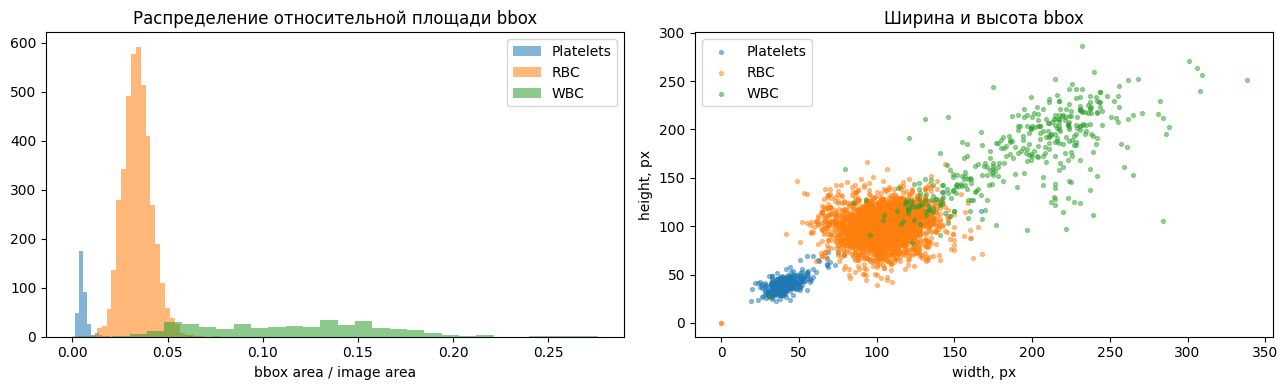

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for cls, part in boxes_df.groupby("class"):
    axes[0].hist(part["relative_area"], bins=30, alpha=0.55, label=cls)
axes[0].set_title("Распределение относительной площади bbox")
axes[0].set_xlabel("bbox area / image area")
axes[0].legend()

for cls, part in boxes_df.groupby("class"):
    axes[1].scatter(part["box_width"], part["box_height"], s=8, alpha=0.45, label=cls)
axes[1].set_title("Ширина и высота bbox")
axes[1].set_xlabel("width, px")
axes[1].set_ylabel("height, px")
axes[1].legend()

plt.tight_layout()

Вывод:
- Platelets занимают <1% изображения (очень маленькие объекты)
- RBC — объекты среднего размера (~3–4% изображения)
- WBC — крупные объекты (до 25% изображения)
- Классы хорошо разделяются по размеру
- Есть 3 чётко разделённых кластера по размеру
- Объекты почти квадратные

In [19]:
COLOR_BY_CLASS = {"RBC": "red", "WBC": "lime", "Platelets": "cyan"}

In [20]:
def resolve_image_path(path_value, image_id):
    path = Path(str(path_value))
    if path.exists():
        return path
    candidates = list((ROOT / "data").glob(f"**/JPEGImages/{image_id}.*"))
    return candidates[0] if candidates else None

In [21]:
def draw_boxes(image_path, boxes):
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)
    for box in boxes:
        cls = box["class"]
        xy = [box["xmin"], box["ymin"], box["xmax"], box["ymax"]]
        draw.rectangle(xy, outline=COLOR_BY_CLASS[cls], width=3)
        draw.text((box["xmin"], max(0, box["ymin"] - 12)), cls, fill=COLOR_BY_CLASS[cls])
    return image

In [22]:
sample = df.sample(min(6, len(df)), random_state=7).copy()
sample["resolved_path"] = [resolve_image_path(p, image_id) for p, image_id in zip(sample["image_path"], sample["image_id"])]
visible = sample.dropna(subset=["resolved_path"])

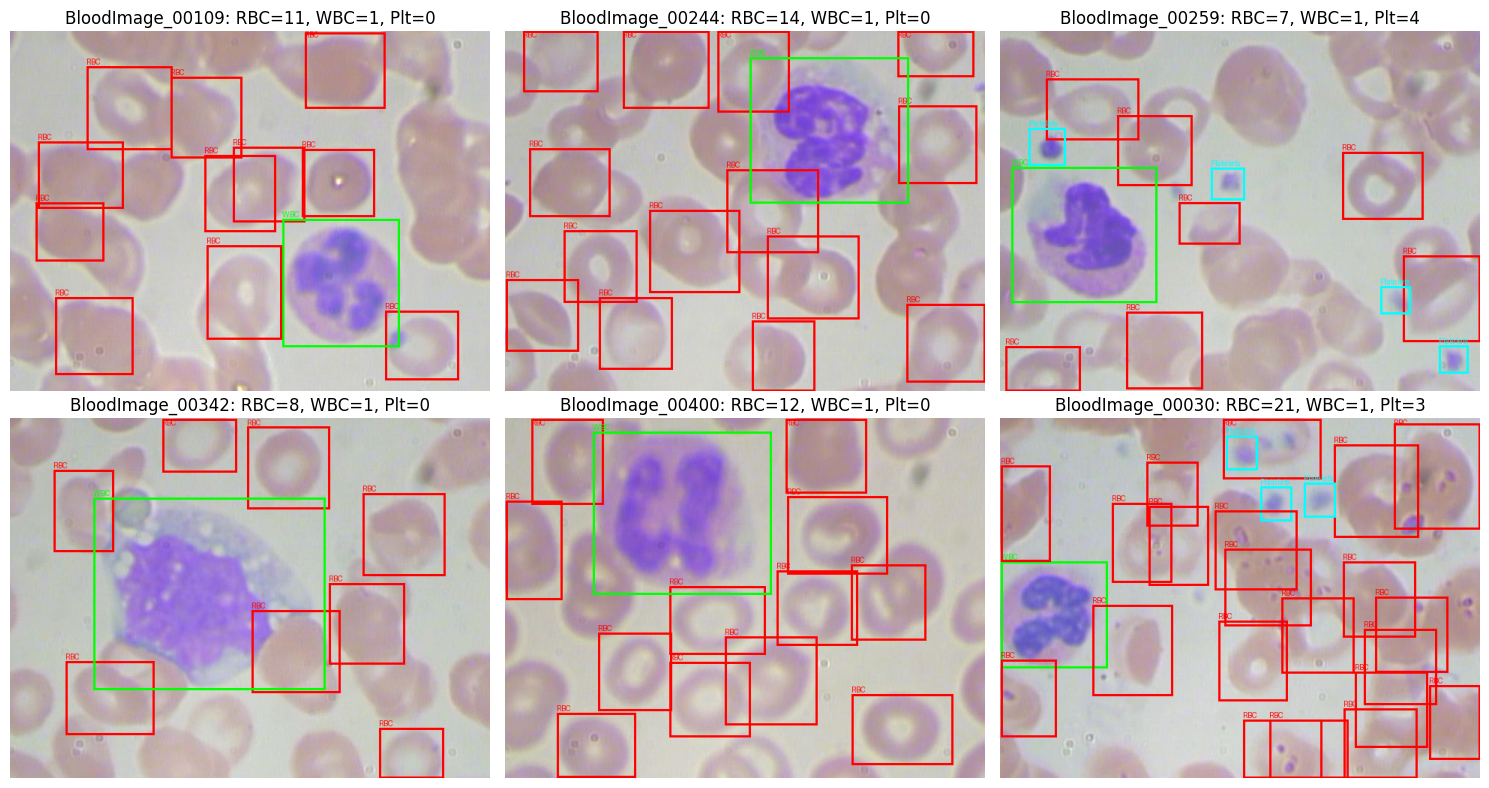

In [25]:
cols = min(3, len(visible))
rows = int(np.ceil(len(visible) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = np.array(axes).reshape(-1)
for ax, (_, row) in zip(axes, visible.iterrows()):
    ax.imshow(draw_boxes(row["resolved_path"], row["boxes"]))
    ax.set_title(f"{row.image_id}: RBC={row.RBC}, WBC={row.WBC}, Plt={row.Platelets}")
    ax.axis("off")
for ax in axes[len(visible):]:
    ax.axis("off")
plt.tight_layout()

Вывод: 
- Разметка визуальна корректна
- bbox не всегда точные

# Результаты обучения

In [38]:
metrics = json.loads(METRICS_JSON.read_text(encoding="utf-8"))
metrics

{'regression_resnet50': {'RBC': {'mae': 3.753424644470215,
   'rmse': 5.0909535975802065,
   'r2': -0.1357102394104004},
  'WBC': {'mae': 0.04109589010477066,
   'rmse': 0.2027212127646504,
   'r2': -0.04285705089569092},
  'Platelets': {'mae': 0.9863013625144958,
   'rmse': 1.2275378971504014,
   'r2': -0.026854276657104492},
  'macro_mae': 1.5936073064804077,
  'macro_rmse': 3.0257646146041703,
  'exact_image_match': 0.0136986301369863},
 'detection_yolo26n_counting': {'RBC': {'mae': 5.246575355529785,
   'rmse': 6.885561512064632,
   'r2': -1.07753324508667},
  'WBC': {'mae': 0.24657534062862396,
   'rmse': 0.5489716528833518,
   'r2': -6.647618293762207},
  'Platelets': {'mae': 1.2876712083816528,
   'rmse': 1.7672825687379177,
   'r2': -1.1283888816833496},
  'macro_mae': 2.2602739334106445,
  'macro_rmse': 4.116455244640457,
  'exact_image_match': 0.0136986301369863},
 'ood_detection': {'threshold_train_p95': 1.780867338180542,
  'clean': {'mean_score': 1.119248628616333, 'ood_ra

In [39]:
def flatten_count_metrics(metrics_dict):
    rows = []
    for model_name, values in metrics_dict.items():
        if not model_name.startswith("regression") and not model_name.startswith("detection"):
            continue
        if isinstance(values, str):
            rows.append({"model": model_name, "class": "all", "metric": "status", "value": values})
            continue
        for cls in CLASSES:
            for metric_name, value in values[cls].items():
                rows.append({"model": model_name, "class": cls, "metric": metric_name, "value": value})
        for metric_name in ["macro_mae", "macro_rmse", "exact_image_match"]:
            rows.append({"model": model_name, "class": "all", "metric": metric_name, "value": values[metric_name]})
    return pd.DataFrame(rows)

In [40]:
count_metrics_long = flatten_count_metrics(metrics)
class_metrics = count_metrics_long[count_metrics_long["class"].isin(CLASSES)].pivot_table(
    index=["model", "class"], columns="metric", values="value"
).round(3)
class_metrics

metric                                  mae     r2   rmse
model                      class                         
detection_yolo26n_counting Platelets  1.288 -1.128  1.767
                           RBC        5.247 -1.078  6.886
                           WBC        0.247 -6.648  0.549
regression_resnet50        Platelets  0.986 -0.027  1.228
                           RBC        3.753 -0.136  5.091
                           WBC        0.041 -0.043  0.203

In [41]:
macro_metrics = count_metrics_long[count_metrics_long["class"].eq("all")].pivot_table(
    index="model", columns="metric", values="value", aggfunc="first"
)
for col in macro_metrics.columns:
    macro_metrics[col] = pd.to_numeric(macro_metrics[col])
display(macro_metrics.round(3))

metric,exact_image_match,macro_mae,macro_rmse
model,,,
detection_yolo26n_counting,0.014,2.260,4.116
regression_resnet50,0.014,1.594,3.026


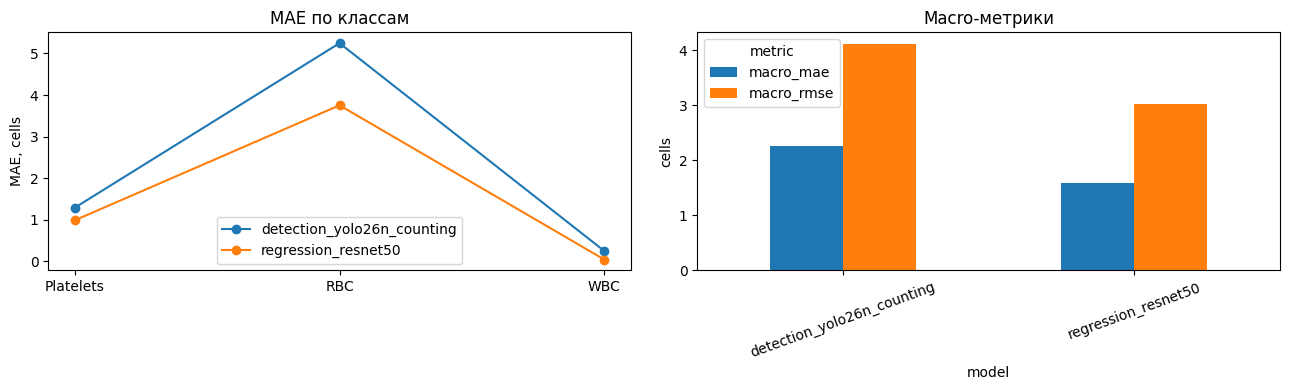

In [42]:
plot_df = class_metrics.reset_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for model_name, part in plot_df.groupby("model"):
    axes[0].plot(part["class"], part["mae"], marker="o", label=model_name)
axes[0].set_title("MAE по классам")
axes[0].set_ylabel("MAE, cells")
axes[0].legend()

macro_plot = macro_metrics[["macro_mae", "macro_rmse"]].astype(float)
macro_plot.plot(kind="bar", ax=axes[1])
axes[1].set_title("Macro-метрики")
axes[1].set_ylabel("cells")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()

Вывод:
- ResNet лучше YOLO (~30%)
- Exact match остаётся 1.4%
- RBC — главный источник ошибки
- Platelets — самый нестабильный класс
- WBC — не проблема

## OOD-детекция

OOD-score считается по признакам ResNet50: на train-fit вычисляются среднее и стандартное отклонение признаков, а для новых изображений берется средний квадрат z-score. Порог OOD — 95-й перцентиль train-score.

Проверяем `clean`, `blur`, `noise` и `external`. `external` — это реальные не-кровяные изображения из `data/external_ood/`

In [43]:
ood = metrics["ood_detection"]
ood_rows = []
for group, values in ood.items():
    if group == "threshold_train_p95":
        continue
    row = {"group": group, **values}
    ood_rows.append(row)

In [44]:
ood_df = pd.DataFrame(ood_rows).set_index("group")
ood_df.round(3)

,mean_score,ood_rate,roc_auc_vs_clean
group,,,
clean,1.119,0.041,NaN
blur,0.748,0.000,0.211
noise,5.497,1.000,1.000
external,453.356,1.000,1.000


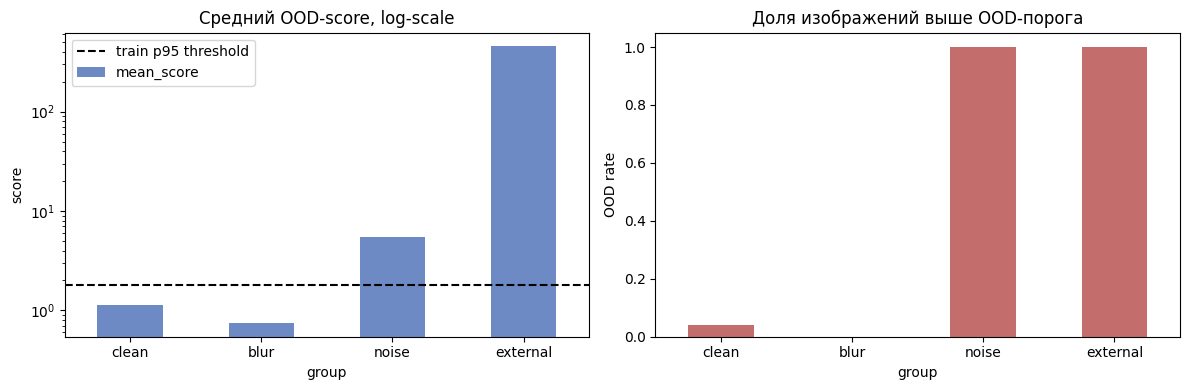

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ood_df["mean_score"].plot(kind="bar", ax=axes[0], color="#6d8ac4", logy=True)
axes[0].axhline(ood["threshold_train_p95"], color="black", linestyle="--", label="train p95 threshold")
axes[0].set_title("Средний OOD-score, log-scale")
axes[0].set_ylabel("score")
axes[0].legend()

ood_df["ood_rate"].plot(kind="bar", ax=axes[1], color="#c46d6d")
axes[1].set_title("Доля изображений выше OOD-порога")
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("OOD rate")

for ax in axes:
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()

Вывод:
- ~4% ложных срабатываний (false positive)
- Детектор не просто не различает blur — он ошибается в обратную сторону
- Идеальное разделение noise vs clean
- External данные радикально отличаются от train
- Детектор чувствителен к распределению, но не к качеству изображения
- Ошибки моделей не объясняются OOD